# Practical 6: Employee Satisfaction Study with Advanced Hypothesis Testing

This notebook is updated according to:
- the **exact attached CSV file** `HR_comma_sep.csv`
- the **Practical 6 flow** from your practical list
- **beginner-friendly code** with clear comments

## Important note
The uploaded file `HR_comma_sep.csv` does **not** contain columns such as:
- `satisfaction_level`
- `sales`
- `salary`
- `time_spend_company`

So this notebook is written only with the **actual columns present** in your attached CSV file.

## Actual columns used from the attached dataset
- `city`
- `education_level`
- `company_type`
- `experience`
- `training_hours`
- `target`

## Practical mapping for this dataset
Because the uploaded dataset is an HR analytics dataset for job-change behavior, we map the practical in a simple way:
- **Numeric score for analysis:** `training_hours`
- **Grouping column for One-Way ANOVA:** `city`
- **Two factors for Two-Way ANOVA:** `education_level` and `company_type`
- **Extra employee outcome column:** `target`


## Step 1: Import Libraries

We import the libraries needed for:
- reading data
- numerical calculations
- graphs
- statistical testing


In [9]:
# pandas is used to work with tabular data like CSV files
import pandas as pd

# numpy is used for numerical calculations
import numpy as np

# matplotlib is used to draw graphs
import matplotlib.pyplot as plt

# seaborn is used to create better statistical graphs
import seaborn as sns

# scipy.stats is used for z-score calculation
from scipy import stats

# statsmodels is used for ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# pairwise_tukeyhsd is used for post-hoc comparison after ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd


## Step 2: Load the Attached Dataset

This notebook uses the attached file:
- `HR_comma_sep.csv`


In [10]:
# Read the CSV file and store it in a DataFrame named df
df = pd.read_csv("HR_comma_sep.csv")

# Display the first 5 rows of the dataset
df.head()


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


## Step 3: Understand the Dataset

This step helps beginners understand:
- number of rows and columns
- column names
- data types
- structure of the dataset


In [11]:
# Print the shape of the dataset
print("Shape of dataset:", df.shape)

# Print all column names
print("\nColumn names in the dataset:")
print(df.columns.tolist())


Shape of dataset: (19158, 14)

Column names in the dataset:
['enrollee_id', 'city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours', 'target']


In [12]:
# Display basic information about the dataset
print("Dataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), in

In [13]:
# Show descriptive statistics for numeric columns
df.describe()


,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


## Step 4: Check Missing Values

The practical requires data curation and cleaning, so first we count missing values.


In [14]:
# Count missing values in each column
missing_values = df.isnull().sum()

# Sort missing values from highest to lowest
missing_values = missing_values.sort_values(ascending=False)

# Display missing value counts
missing_values


company_type              6140
company_size              5938
gender                    4508
major_discipline          2813
education_level            460
last_new_job               423
enrolled_university        386
experience                  65
enrollee_id                  0
city                         0
city_development_index       0
relevent_experience          0
training_hours               0
target                       0
dtype: int64

## Step 5: Select Useful Columns for This Practical

To keep the notebook simple and error-free, we use only the exact columns that are present in your attached dataset.

### Selected columns
- `city` → grouping variable
- `education_level` → categorical factor
- `company_type` → categorical factor
- `experience` → employee experience
- `training_hours` → numeric score for analysis
- `target` → job-change target


In [15]:
# Select useful columns from the attached dataset
selected_columns = [
    "city",             # city of the employee
    "education_level",  # education category
    "company_type",     # type of company
    "experience",       # years of experience
    "training_hours",   # numeric score used for analysis
    "target"            # target/output column
]

# Create a new DataFrame using only the selected columns
df_selected = df[selected_columns].copy()

# Display the first 5 rows
df_selected.head()


,city,education_level,company_type,experience,training_hours,target
0,city_103,Graduate,NaN,>20,36,1.0
1,city_40,Graduate,Pvt Ltd,15,47,0.0
2,city_21,Graduate,NaN,5,83,0.0
3,city_115,Graduate,Pvt Ltd,<1,52,1.0
4,city_162,Masters,Funded Startup,>20,8,0.0


## Step 6: Handle Missing Values

For beginner students, we use a simple method:
- remove rows where the selected columns contain missing values


In [16]:
# Check missing values in the selected columns
df_selected.isnull().sum()


city                  0
education_level     460
company_type       6140
experience           65
training_hours        0
target                0
dtype: int64

In [17]:
# Remove rows with missing values in selected columns
df_clean = df_selected.dropna()

# Print shape before and after cleaning
print("Original shape:", df_selected.shape)
print("Shape after removing missing values:", df_clean.shape)


Original shape: (19158, 6)
Shape after removing missing values: (12830, 6)


## Step 7: Keep Top 5 Cities for Easy Analysis

The `city` column has many categories.  
For beginner-friendly ANOVA and cleaner plots, we keep only the **top 5 cities** by frequency.


In [18]:
# Find top 5 cities with the highest number of rows
top_5_cities = df_clean["city"].value_counts().head(5).index.tolist()

# Print the selected cities
print("Top 5 cities used for analysis:", top_5_cities)


Top 5 cities used for analysis: ['city_103', 'city_21', 'city_16', 'city_114', 'city_160']


In [19]:
# Keep only rows from the top 5 cities
df_top_cities = df_clean[df_clean["city"].isin(top_5_cities)].copy()

# Print the shape after filtering
print("Shape after keeping top 5 cities:", df_top_cities.shape)


Shape after keeping top 5 cities: (7535, 6)


## Step 8: Stratified Random Sampling

The practical asks for a sampling technique such as stratified random sampling.

Here:
- each city is treated as one stratum
- we take 30% sample from each city
- this keeps every selected city represented in the sample


In [20]:
# Set the sampling fraction
sampling_fraction = 0.30

# Perform stratified sampling by city
df_sampled = df_top_cities.groupby("city", group_keys=False).apply(
    lambda x: x.sample(frac=sampling_fraction, random_state=42)
)

# Reset index after sampling
df_sampled = df_sampled.reset_index(drop=True)

# Print the shape of sampled data
print("Shape of sampled data:", df_sampled.shape)

# Display the first 5 rows
df_sampled.head()


Shape of sampled data: (2261, 6)


,city,education_level,company_type,experience,training_hours,target
0,city_103,Masters,Pvt Ltd,16,29,0.0
1,city_103,Graduate,Pvt Ltd,6,46,0.0
2,city_103,Graduate,Pvt Ltd,7,28,0.0
3,city_103,Masters,Pvt Ltd,4,23,0.0
4,city_103,Graduate,Pvt Ltd,>20,121,0.0


In [21]:
# Explain why stratified sampling was used
print("Stratified sampling was used so that each selected city remains represented in the sample.")
print("This helps make the sample balanced for group comparison.")


Stratified sampling was used so that each selected city remains represented in the sample.
This helps make the sample balanced for group comparison.


## Step 9: Outlier Analysis Using Box Plot

The practical asks for outlier analysis.

We use the numeric column `training_hours`.


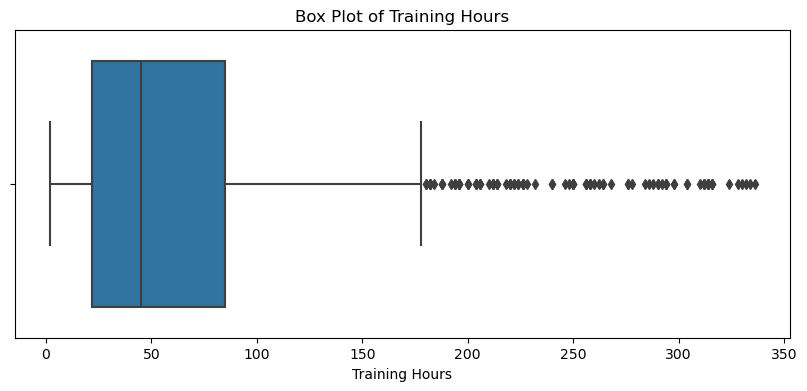

In [22]:
# Create a figure for the box plot
plt.figure(figsize=(10, 4))

# Draw the box plot of training_hours
sns.boxplot(x=df_sampled["training_hours"])

# Add title and label
plt.title("Box Plot of Training Hours")
plt.xlabel("Training Hours")

# Show the plot
plt.show()


## Step 10: Outlier Detection Using Z-Score

A common beginner rule is:
- if absolute Z-score > 3, treat the value as a possible outlier


In [23]:
# Calculate absolute z-scores for training_hours
z_scores = np.abs(stats.zscore(df_sampled["training_hours"]))

# Add z-score as a new column
df_sampled["z_score"] = z_scores

# Keep only rows where z-score is less than or equal to 3
df_no_outliers = df_sampled[df_sampled["z_score"] <= 3].copy()

# Print shape before and after removing outliers
print("Shape before removing outliers:", df_sampled.shape)
print("Shape after removing outliers :", df_no_outliers.shape)


Shape before removing outliers: (2261, 7)
Shape after removing outliers : (2208, 7)


## Step 11: Group Means Before ANOVA

Before ANOVA, it is useful to see the average `training_hours` for each selected city.


In [24]:
# Calculate mean training_hours for each city
city_means = df_no_outliers.groupby("city")["training_hours"].mean()

# Print the result
print("Mean training hours by city:")
print(city_means)


Mean training hours by city:
city
city_103    56.653128
city_114    53.660959
city_16     59.393750
city_160    59.638710
city_21     56.733962
Name: training_hours, dtype: float64


## Step 12: One-Way ANOVA

### Goal
To test whether the mean `training_hours` is significantly different across cities.

### Hypotheses
- **H0:** Mean training hours are the same across all selected cities
- **H1:** At least one city has a different mean training hours


In [25]:
# Build the One-Way ANOVA model
one_way_model = ols('training_hours ~ C(city)', data=df_no_outliers).fit()

# Create the ANOVA table
one_way_anova_table = sm.stats.anova_lm(one_way_model, typ=2)

# Display the ANOVA table
one_way_anova_table


,sum_sq,df,F,PR(>F)
C(city),6.285619e+03,4.0,0.731177,0.570607
Residual,4.734561e+06,2203.0,NaN,NaN


In [26]:
# Extract the p-value from the ANOVA table
one_way_p_value = one_way_anova_table["PR(>F)"][0]

# Print the p-value
print("One-Way ANOVA p-value:", one_way_p_value)

# Interpret the result using significance level 0.05
if one_way_p_value < 0.05:
    print("Result: Reject the null hypothesis.")
    print("Conclusion: Mean training hours are significantly different across cities.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("Conclusion: Mean training hours are not significantly different across cities.")


One-Way ANOVA p-value: 0.5706069760047774
Result: Fail to reject the null hypothesis.
Conclusion: Mean training hours are not significantly different across cities.


## Step 13: Tukey's HSD Post-Hoc Test

If One-Way ANOVA is significant, Tukey's HSD helps identify which exact city pairs are different.


In [27]:
# Run Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(
    endog=df_no_outliers["training_hours"],
    groups=df_no_outliers["city"],
    alpha=0.05
)

# Print the Tukey HSD result
print(tukey_result)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
city_103 city_114  -2.9922 0.8731 -11.5032  5.5189  False
city_103  city_16   2.7406 0.8933  -5.4836 10.9649  False
city_103 city_160   2.9856 0.9468  -8.0109 13.9821  False
city_103  city_21   0.0808    1.0  -6.8333  6.9949  False
city_114  city_16   5.7328 0.5443  -4.5098 15.9754  False
city_114 city_160   5.9778 0.6928  -6.5998 18.5553  False
city_114  city_21    3.073 0.8933  -6.1507 12.2968  False
 city_16 city_160    0.245    1.0 -12.1404 12.6303  False
 city_16  city_21  -2.6598 0.9275 -11.6196     6.3  False
city_160  city_21  -2.9047 0.9595 -14.4617  8.6522  False
---------------------------------------------------------


## Step 14: Prepare Data for Two-Way ANOVA

For Two-Way ANOVA, we use:
- `education_level`
- `company_type`

We remove rows with missing values in these two factors from the dataset already cleaned and filtered.


In [28]:
# Keep only rows where education_level and company_type are available
df_two_way = df_no_outliers.dropna(subset=["education_level", "company_type"]).copy()

# Print the shape of the dataset used for Two-Way ANOVA
print("Shape used for Two-Way ANOVA:", df_two_way.shape)

# Display the first 5 rows
df_two_way.head()


Shape used for Two-Way ANOVA: (2208, 7)


,city,education_level,company_type,experience,training_hours,target,z_score
0,city_103,Masters,Pvt Ltd,16,29,0.0,0.576698
1,city_103,Graduate,Pvt Ltd,6,46,0.0,0.282157
2,city_103,Graduate,Pvt Ltd,7,28,0.0,0.594024
3,city_103,Masters,Pvt Ltd,4,23,0.0,0.680653
4,city_103,Graduate,Pvt Ltd,>20,121,0.0,1.017286


## Step 15: Two-Way ANOVA

### Goal
To test whether:
- `education_level`
- `company_type`
- and their interaction

have a significant effect on `training_hours`.


In [29]:
# Build the Two-Way ANOVA formula
two_way_formula = 'training_hours ~ C(education_level) + C(company_type) + C(education_level):C(company_type)'

# Fit the model
two_way_model = ols(two_way_formula, data=df_two_way).fit()

# Create the Two-Way ANOVA table
two_way_anova_table = sm.stats.anova_lm(two_way_model, typ=2)

# Display the table
two_way_anova_table


C:\Users\CHARUSAT\anaconda3\Lib\site-packages\statsmodels\base\model.py:1888: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 2
  warnings.warn('covariance of constraints does not have full '
C:\Users\CHARUSAT\anaconda3\Lib\site-packages\statsmodels\base\model.py:1888: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 2
  warnings.warn('covariance of constraints does not have full '
C:\Users\CHARUSAT\anaconda3\Lib\site-packages\statsmodels\base\model.py:1888: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 16
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(education_level),1.049576e+02,4.0,0.012261,0.987814
C(company_type),2.610534e+03,5.0,0.243961,0.783539
C(education_level):C(company_type),5.578795e+04,20.0,1.303384,0.185470
Residual,4.671882e+06,2183.0,NaN,NaN


In [30]:
# Read the p-values from the Two-Way ANOVA table
p_education = two_way_anova_table["PR(>F)"][0]
p_company = two_way_anova_table["PR(>F)"][1]
p_interaction = two_way_anova_table["PR(>F)"][2]

# Print the p-values clearly
print("P-value for education_level effect :", p_education)
print("P-value for company_type effect    :", p_company)
print("P-value for interaction effect     :", p_interaction)


P-value for education_level effect : 0.9878142044808922
P-value for company_type effect    : 0.7835392105181753
P-value for interaction effect     : 0.18546998981780308


In [31]:
# Interpret the education_level effect
if p_education < 0.05:
    print("education_level has a statistically significant effect on training_hours.")
else:
    print("education_level does not have a statistically significant effect on training_hours.")

# Interpret the company_type effect
if p_company < 0.05:
    print("company_type has a statistically significant effect on training_hours.")
else:
    print("company_type does not have a statistically significant effect on training_hours.")

# Interpret the interaction effect
if p_interaction < 0.05:
    print("There is a statistically significant interaction between education_level and company_type.")
else:
    print("There is no statistically significant interaction between education_level and company_type.")


education_level does not have a statistically significant effect on training_hours.
company_type does not have a statistically significant effect on training_hours.
There is no statistically significant interaction between education_level and company_type.


## Step 16: Helpful Visualizations for Group Comparison

These plots help beginners understand group differences visually.


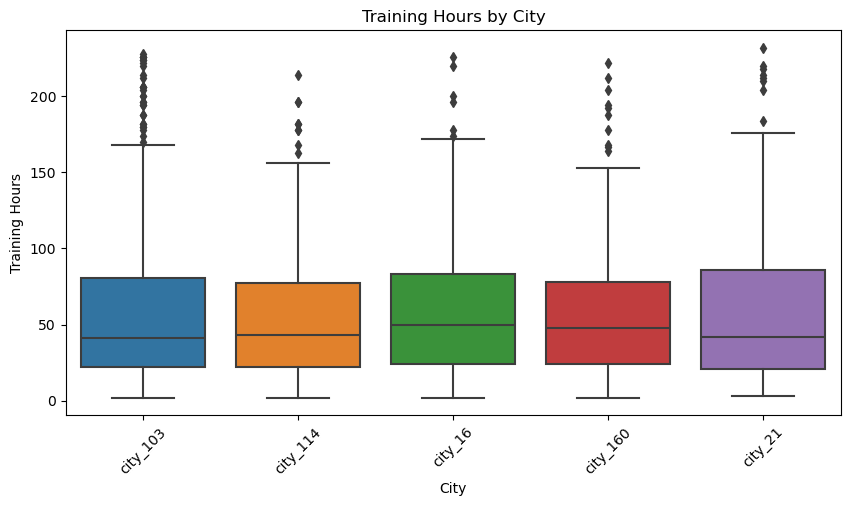

In [32]:
# Create a box plot of training_hours by city
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_no_outliers["city"], y=df_no_outliers["training_hours"])
plt.title("Training Hours by City")
plt.xlabel("City")
plt.ylabel("Training Hours")
plt.xticks(rotation=45)
plt.show()


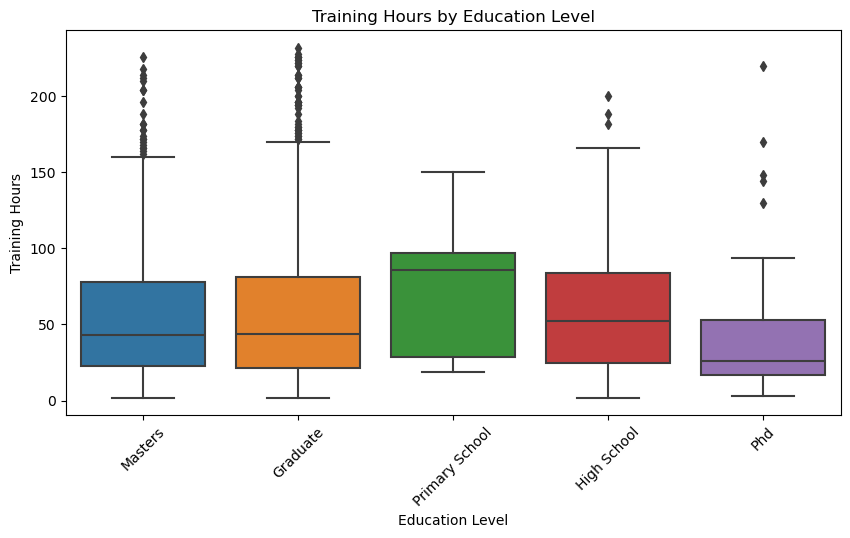

In [33]:
# Create a box plot of training_hours by education_level
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_two_way["education_level"], y=df_two_way["training_hours"])
plt.title("Training Hours by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Training Hours")
plt.xticks(rotation=45)
plt.show()


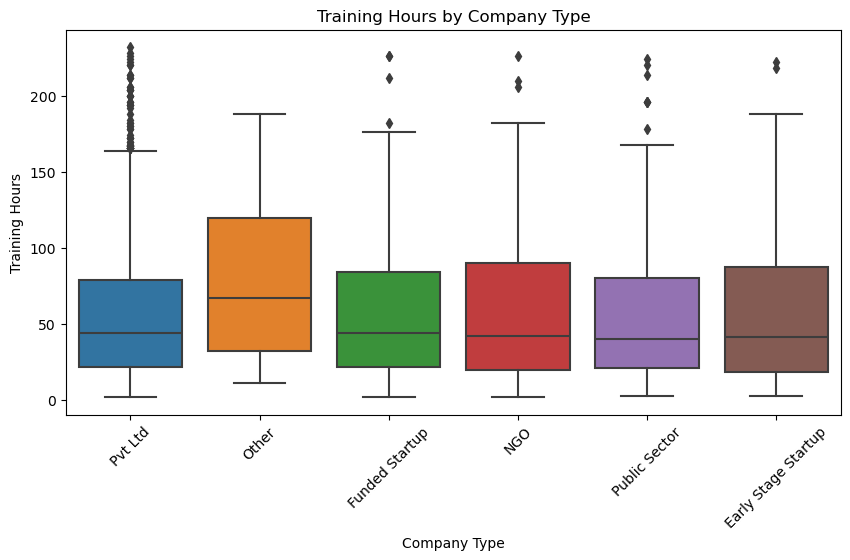

In [34]:
# Create a box plot of training_hours by company_type
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_two_way["company_type"], y=df_two_way["training_hours"])
plt.title("Training Hours by Company Type")
plt.xlabel("Company Type")
plt.ylabel("Training Hours")
plt.xticks(rotation=45)
plt.show()


## Step 17: Final Conclusion

Students can write the final conclusion based on:
- why stratified sampling was used
- whether outliers were found
- whether city-wise differences were significant
- whether education level affected training hours
- whether company type affected training hours
- whether the interaction between education level and company type was significant
- which city pairs were significantly different according to Tukey's HSD


# 🔷 TASK SET 2: Practical 6

---

## 🧠 Task 1: Hypothesis Design

### 📌 Instructions:
Create **3 hypotheses** using dataset.

Example:
- Does salary affect satisfaction?

For each:
- Define **H₀ (Null Hypothesis)**
- Define **H₁ (Alternative Hypothesis)**

---

## 📊 Task 2: Visual vs Statistical Comparison

### 📌 Instructions:
1. Plot:
   - Boxplot (satisfaction vs department)
2. Compare with ANOVA result

### Answer:
- Do visual differences match ANOVA result?
- If not, explain why

---

## ⚙️ Task 3: Group Comparison (Tukey)

### 📌 Instructions:
Using Tukey test output:

1. Identify:
   - Most similar groups
   - Most different groups

2. Explain possible reasons

---

## 🧠 Task 4: Business Interpretation

### 📌 Instructions:
You are HR Manager.

1. Identify department with lowest satisfaction
2. Suggest **2 improvements**
3. Justify using ANOVA results

---

## 🔬 Task 5: Interaction Effect

### 📌 Instructions:
Analyze:

- Department + Salary

### Answer:
1. Does satisfaction depend on both?
2. Explain interaction effect with real example

---

## 🧪 Task 6: When ANOVA is NOT Significant

### 📌 Instructions:
Suppose:

p-value > 0.05

### Answer:
1. What does it mean?
2. Does it mean groups are identical?
3. What should analyst do next?

---

## Practical-6 Submission Section (Minimum Required)

Proxy mapping used from HR dataset:
- location -> city
- department -> major_discipline
- satisfaction_score (proxy) -> scaled blend of training_hours and target

This section covers stratified sampling, outlier analysis, one-way ANOVA, and two-way ANOVA.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import f_oneway, zscore
import statsmodels.api as sm
from statsmodels.formula.api import ols

sns.set(style="whitegrid")

df = pd.read_csv("HR_comma_sep.csv")
print("Dataset shape:", df.shape)

# Proxy mapping approved by user
# location -> city
# department -> major_discipline
# satisfaction_score -> scaled blend of training_hours and target

df = df.copy()
df["location"] = df["city"].astype(str)
df["department"] = df["major_discipline"].fillna("Unknown").astype(str)

th = df["training_hours"].fillna(df["training_hours"].median())
th_scaled = 100 * (th - th.min()) / (th.max() - th.min() + 1e-9)
target_scaled = 100 * df["target"].fillna(df["target"].median())
df["satisfaction_score"] = 0.6 * th_scaled + 0.4 * target_scaled

# Keep required columns
work = df[["location", "department", "satisfaction_score"]].dropna().copy()

# Stratified random sampling by department
sampled = (
    work.groupby("department", group_keys=False)
    .apply(lambda x: x.sample(frac=0.3, random_state=42) if len(x) > 3 else x)
    .reset_index(drop=True)
)
print("\nOriginal rows:", len(work), "| Stratified sampled rows:", len(sampled))

# Outlier analysis (Z-score + boxplot)
sampled["z_score"] = zscore(sampled["satisfaction_score"])
outliers = sampled[np.abs(sampled["z_score"]) > 3]
print("Outliers detected with |z|>3:", len(outliers))

plt.figure(figsize=(8, 4))
sns.boxplot(x=sampled["satisfaction_score"])
plt.title("Outlier View: Satisfaction Score (Proxy)")
plt.tight_layout()
plt.show()

# One-way ANOVA across top locations (enough observations)
loc_counts = sampled["location"].value_counts()
valid_locations = loc_counts[loc_counts >= 20].index[:5]
oneway_data = sampled[sampled["location"].isin(valid_locations)].copy()
groups = [g["satisfaction_score"].values for _, g in oneway_data.groupby("location")]

if len(groups) >= 2:
    f_stat, p_val = f_oneway(*groups)
    print("\nOne-way ANOVA (satisfaction_score by location)")
    print("F-statistic:", round(float(f_stat), 4))
    print("p-value:", round(float(p_val), 6))
else:
    print("\nOne-way ANOVA skipped: not enough valid location groups.")

# Two-way ANOVA using reduced levels to avoid sparse interaction matrix
top_depts = sampled["department"].value_counts().index[:4]
top_locs = sampled["location"].value_counts().index[:4]
twoway_data = sampled[sampled["department"].isin(top_depts) & sampled["location"].isin(top_locs)].copy()

model = ols("satisfaction_score ~ C(department) + C(location) + C(department):C(location)", data=twoway_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("\nTwo-way ANOVA (department, location, interaction):")
display(anova_table)

print("\nInterpretation (minimum):")
print("Use p-value < 0.05 to conclude statistically significant group differences or interaction effects.")